## Quality grading results

In [ ]:
%load_ext autoreload
%autoreload 2

# Run in parent dir
import os

os.chdir("../")

import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from utils import helpers, nako, plot

device = 'cuda:0'
pd.options.display.float_format = "{:,.2f}".format
plot.set_rc_params(kind='paper', notebook_dpi=120)

In [ ]:
# Where results of the quality filter are stored
project_dir = Path.cwd()
nako_paths = nako.get_nako_paths('590', 'baseline', 'images_lowres', '512_raw')
quality_dir = nako_paths['quality_dir']
n_participants = 104000 if 'followup' in nako_paths['nako_dir'] else 48460
n_images = 397247 if 'followup' in nako_paths['nako_dir'] else 203493

# Threshold for the quality prediction: values below this threshold are considered as bad quality
threshold = 0.25

# List of corrupted and ungradable images
corrupted_images, low_res_images, ungradable_images = nako.get_unusable_images(nako_paths['quality_dir'])

### Percentage of non-corrupted and gradable images

In [17]:
# Number of fundus images per type
df_images = pd.DataFrame(columns=['Type', 'Index', 'All', 'Usable', 'Gradable'])

for i, image_type in enumerate(nako.IMAGE_TYPES):
    for j in range(1, 4):
        image_dir = os.path.join(nako_paths['nako_dir'], 'images', image_type + '_' + str(j))
        all_images = glob.glob(os.path.join(image_dir, '*.jpg'))
        all_images = ['/'.join(p.split(sep='/')[-2:]) for p in all_images]

        # Filter out corrupted images
        usable_images = list(set(all_images).difference(set(corrupted_images + low_res_images)))

        # Filter out ungradable images
        gradable_images = list(set(usable_images).difference(set(ungradable_images)))

        df_images_append = pd.DataFrame([{'Type':image_type, 'Index': j, 'All': len(all_images), 'Usable': len(usable_images), 'Gradable': len(gradable_images)}])
        df_images = pd.concat([df_images, df_images_append], ignore_index=True)

df_images['All %'] = df_images['All'] * 100 / n_participants   
df_images['Usable %'] = df_images['Usable'] * 100 / n_participants
df_images['Gradable %'] = df_images['Gradable'] * 100 / n_participants

df_images

,Type,Index,All,Usable,Gradable,All %,Usable %,Gradable %
0,rt_leftcentral,1,47907,47820,36126,98.86,98.68,74.55
1,rt_leftcentral,2,3075,3061,1375,6.35,6.32,2.84
2,rt_leftcentral,3,158,158,63,0.33,0.33,0.13
3,rt_leftnasal,1,47931,47858,34454,98.91,98.76,71.10
4,rt_leftnasal,2,3034,3022,1599,6.26,6.24,3.30
5,rt_leftnasal,3,147,147,81,0.30,0.30,0.17
6,rt_rightcentral,1,47986,47914,39689,99.02,98.87,81.90
7,rt_rightcentral,2,2271,2259,991,4.69,4.66,2.04
8,rt_rightcentral,3,91,90,21,0.19,0.19,0.04
9,rt_rightnasal,1,48015,47936,39716,99.08,98.92,81.96


### Ungradable images

In [ ]:
image_dir = os.path.join(nako_paths['image_dir'], nako.IMAGE_TYPES[1]  + '_' + str(1))
results_file = quality_dir.joinpath('fundus_image_toolbox', os.path.basename(image_dir) + '.csv')
df = pd.read_csv(results_file, dtype={'ID': str})

# ungradable = df[(df['confidence'] <= 0.16) & (df['confidence'] > 0.14)]
ungradable = df[(df['confidence'] <= 0.26) & (df['confidence'] > 0.24)]

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(14,4))
ax = ax.flatten()

for i in range(4):
    idx = np.random.randint(0, ungradable.shape[0])
    img = ungradable.iloc[idx, 0]
    score = ungradable.iloc[idx, 1]
    
    ax[i].imshow(helpers.load_image(os.path.join(image_dir, img + '.jpg')))
    ax[i].title.set_text(f'Score = {score}')
    ax[i].axes.get_xaxis().set_visible(False)
    ax[i].axes.get_yaxis().set_visible(False)

### Comparison between quality filters
* Fundus Image Toolbox (BerensLab)
* RetiRatey (UCL)
* AutoMorph
* VascX

#### 1. Preprocess results

In [ ]:
# Set label for RetiRatey
for image_type in nako.IMAGE_TYPES:
    for i in range(1, 4):
        quality_file = quality_dir.joinpath('retiratey', f'{image_type}_{str(i)}.csv')
        quality_df = pd.read_csv(quality_file, dtype={'ID': str})

        quality_df['label'] = ((quality_df['disc'] <= 3) & (quality_df['macula'] <= 3) & (quality_df['vessels'] <= 3)).astype(int)

        quality_df.to_csv(quality_file, mode='w', index=False, header=True, float_format='%.3f')

In [ ]:
# Clean automorph results
for image_type in nako.IMAGE_TYPES:
    for i in range(1, 4):
        quality_file = quality_dir.joinpath('automorph', f'{image_type}_{str(i)}.csv')
        quality_df = pd.read_csv(quality_file, dtype={'ID': str})

        if 'Name' in quality_df.columns:
            quality_df['Name'] = quality_df['Name'].apply(lambda x: os.path.basename(x).split(sep='.')[0])
            quality_df.rename(columns={'Name': 'ID'}, inplace=True)
        quality_df['prediction_label'] = quality_df['Prediction'].map({0: 'Good', 1: 'Usable', 2: 'Reject'})
        quality_df['label'] = (quality_df['Prediction'] != 2).astype(int)

        quality_df.to_csv(quality_file, mode='w', index=False, header=True)

In [ ]:
# Clean VascX results
for image_type in nako.IMAGE_TYPES:
    for i in range(1, 4):
        quality_file = quality_dir.joinpath('vascx', f'{image_type}_{str(i)}.csv')
        quality_df = pd.read_csv(quality_file, dtype={'ID': str})

        if 'Unnamed: 0' in quality_df.columns:
            quality_df.rename(columns={'Unnamed: 0': 'ID'}, inplace=True)
        quality_df['prediction'] = quality_df[['q1', 'q2', 'q3']].idxmax(axis=1)
        quality_df['prediction_label'] = quality_df['prediction'].map({'q1': 'Good', 'q2': 'Usable', 'q3': 'Reject'})
        quality_df['label'] = (quality_df['prediction_label'] != 'Reject').astype(int)
        quality_df.to_csv(quality_file, mode='w', index=False, header=True)

#### 2. Load results

In [6]:
# Load results from all quality filters
fit, retiratey, automorph, vascx = {}, {}, {}, {}

for image_type in nako.IMAGE_TYPES:
    for i in range(1, 4):
        quality_file = quality_dir.joinpath('fundus_image_toolbox', f'{image_type}_{str(i)}.csv')
        fit[f'{image_type}_{i}'] = pd.read_csv(quality_file, dtype={'ID': str})

        quality_file = quality_dir.joinpath('retiratey', f'{image_type}_{str(i)}.csv')
        retiratey[f'{image_type}_{i}'] = pd.read_csv(quality_file, dtype={'ID': str})

        quality_file = quality_dir.joinpath('automorph', f'{image_type}_{str(i)}.csv')
        automorph[f'{image_type}_{i}'] = pd.read_csv(quality_file, dtype={'ID': str})

        quality_file = quality_dir.joinpath('vascx', f'{image_type}_{str(i)}.csv')
        vascx[f'{image_type}_{i}'] = pd.read_csv(quality_file, dtype={'ID': str})

#### 3. Percentage of participants with gradable images

In [7]:
df_quality = pd.DataFrame(columns=['Type', 'All', 'Usable', 'Usable %', 'Gradable (FIT)', 'Gradable (FIT) %', 'Gradable (RetiRatey)', 'Gradable (RetiRatey) %', 'Gradable (AutoMorph)', 'Gradable (AutoMorph) %', 'Gradable (VascX)', 'Gradable (VascX) %', 'Gradable (All)', 'Gradable (All) %'])
df_quality = df_quality.astype(dict(zip(df_quality.columns, [str, int, int, float, int, float, int, float, int, float, int, float])))

for image_type in nako.IMAGE_TYPES:
    all, usable, gradable_fit, gradable_retiratey, gradable_automorph, gradable_vascx, gradable_all = [], [], [], [], [], [], []
    for i in range(1, 4):
        image_dir = os.path.join(nako_paths['nako_dir'], 'images', image_type + '_' + str(i))
        all_images = glob.glob(os.path.join(image_dir, '*.jpg'))
        all_images = ['/'.join(p.split(sep='/')[-2:]) for p in all_images]
        all_ids = [p.split(sep='/')[-1] for p in all_images]
        all.extend(all_ids)

        # Usable Images
        usable_images = list(set(all_images).difference(set(corrupted_images + low_res_images)))
        usable_ids = [p.split(sep='/')[-1] for p in usable_images]
        usable.extend(usable_ids)

        # Gradable FIT
        quality_df = fit[f'{image_type}_{i}']
        gradable_ids = quality_df[quality_df['label'] == 1]['ID'].to_list()
        gradable_fit.extend(gradable_ids)

        # Gradable RetiRatey
        quality_df = retiratey[f'{image_type}_{i}']
        gradable_ids = quality_df[quality_df['label'] == 1]['ID'].to_list()
        gradable_retiratey.extend(gradable_ids)

        # Gradable AutoMorph
        quality_df = automorph[f'{image_type}_{i}']
        gradable_ids = quality_df[quality_df['label'] == 1]['ID'].to_list()
        gradable_automorph.extend(gradable_ids)

        # Gradable VascX
        quality_df = vascx[f'{image_type}_{i}']
        gradable_ids = quality_df[quality_df['label'] == 1]['ID'].to_list()
        gradable_vascx.extend(gradable_ids)

        gradable_all.extend(list(set(gradable_fit).intersection(set(gradable_retiratey)).intersection(set(gradable_automorph)).intersection(set(gradable_vascx))))

    df_quality_append = pd.DataFrame([{'Type':image_type, 'All': len(set(all)), 'Usable': len(set(usable)), 'Usable %': len(set(usable)) * 100 / n_participants,
                                       'Gradable (FIT)': len(set(gradable_fit)), 'Gradable (FIT) %': len(set(gradable_fit)) * 100 / n_participants,
                                       'Gradable (RetiRatey)': len(set(gradable_retiratey)), 'Gradable (RetiRatey) %': len(set(gradable_retiratey)) * 100 / n_participants,
                                       'Gradable (AutoMorph)': len(set(gradable_automorph)), 'Gradable (AutoMorph) %': len(set(gradable_automorph)) * 100 / n_participants,
                                       'Gradable (VascX)': len(set(gradable_vascx)), 'Gradable (VascX) %': len(set(gradable_vascx)) * 100 / n_participants,
                                       'Gradable (All)': len(set(gradable_all)), 'Gradable (All) %': len(set(gradable_all)) * 100 / n_participants }])
    df_quality = pd.concat([df_quality, df_quality_append], ignore_index=True)

df_quality

/tmp/ipykernel_2867485/3274234258.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_quality = pd.concat([df_quality, df_quality_append], ignore_index=True)


,Type,All,Usable,Usable %,Gradable (FIT),Gradable (FIT) %,Gradable (RetiRatey),Gradable (RetiRatey) %,Gradable (AutoMorph),Gradable (AutoMorph) %,Gradable (VascX),Gradable (VascX) %,Gradable (All),Gradable (All) %
0,rt_leftcentral,47912,47826,98.69,37158,76.68,41036,84.68,37755,77.91,39903,82.34,36299,74.91
1,rt_leftnasal,47932,47861,98.76,35202,72.64,43233,89.21,33964,70.09,31437,64.87,28356,58.51
2,rt_rightcentral,47989,47919,98.88,40248,83.05,43784,90.35,41383,85.40,42480,87.66,39409,81.32
3,rt_rightnasal,48019,47943,98.93,40526,83.63,44303,91.42,38901,80.27,35021,72.27,33065,68.23


#### 4. Score distribution

In [8]:
scores_fit = pd.DataFrame(columns=['ID', 'confidence'])
scores_fit = scores_fit.astype(dict(zip(scores_fit.columns, [str, float])))

scores_retiratey = pd.DataFrame(columns=['ID', 'disc', 'macula', 'vessels'])
scores_retiratey = scores_retiratey.astype(dict(zip(scores_retiratey.columns, [str, float, float, float])))

scores_automorph = pd.DataFrame(columns=['ID', 'prediction_label'])
scores_automorph = scores_automorph.astype(dict(zip(scores_automorph.columns, [str, float])))

scores_vascx = pd.DataFrame(columns=['ID', 'prediction_label'])
scores_vascx = scores_vascx.astype(dict(zip(scores_vascx.columns, [str, float])))

for image_type in nako.IMAGE_TYPES:
    for i in range(1, 4):
        # Scores for FIT
        quality_df = fit[f'{image_type}_{i}']
        scores_fit = pd.concat([scores_fit, quality_df[scores_fit.columns]], ignore_index=True)

        # Scores for RetiRatey
        quality_df = retiratey[f'{image_type}_{i}']
        scores_retiratey = pd.concat([scores_retiratey, quality_df[scores_retiratey.columns]], ignore_index=True)

        # Scores for Automorph
        quality_df = automorph[f'{image_type}_{i}']
        scores_automorph = pd.concat([scores_automorph, quality_df[scores_automorph.columns]], ignore_index=True)

        # Scores for Automorph
        quality_df = vascx[f'{image_type}_{i}']
        scores_vascx = pd.concat([scores_vascx, quality_df[scores_vascx.columns]], ignore_index=True)

# List scores per area for kde plot
score = scores_retiratey['disc'].to_list() + scores_retiratey['macula'].to_list() + scores_retiratey['vessels'].to_list()
region = ['disc'] * scores_retiratey.shape[0] + ['macula'] * scores_retiratey.shape[0] + ['vessels'] * scores_retiratey.shape[0]
scores_retiratey = pd.DataFrame({'Score': score, 'Region': region})

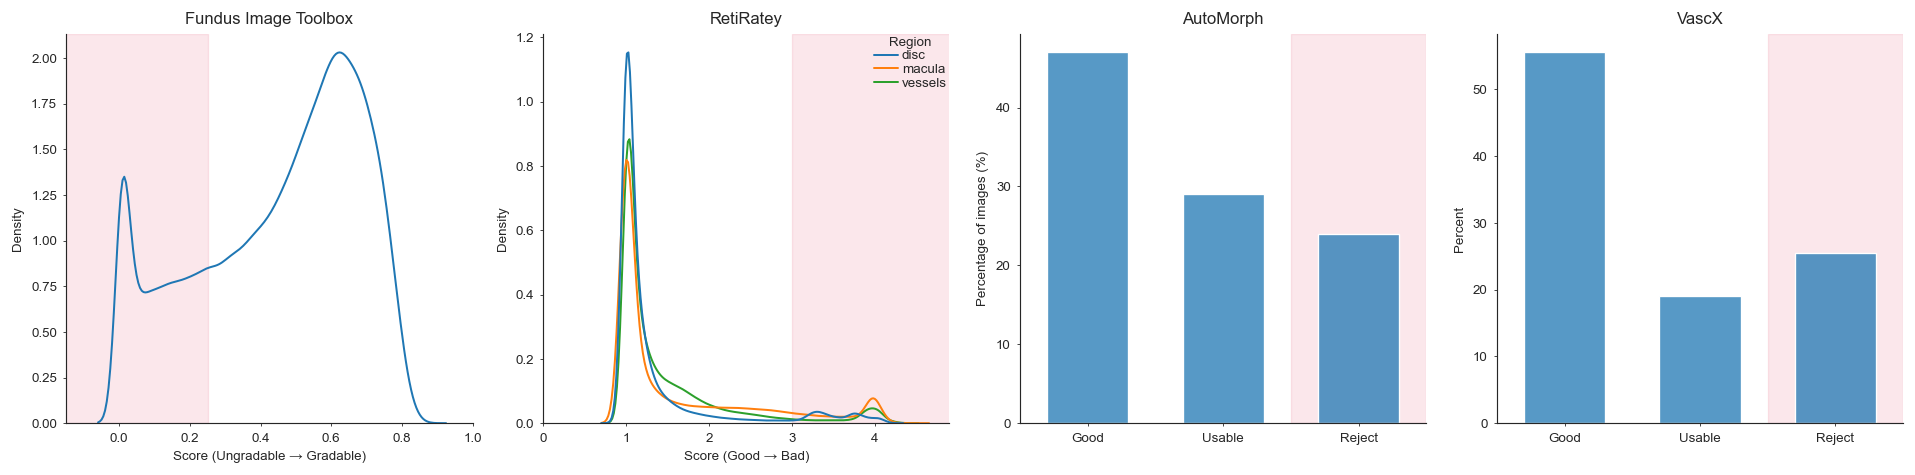

In [9]:
# Distribution plot
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

# Set thresholds
ax[0].axvspan(-0.2, 0.25, color='crimson', alpha=0.1)
ax[1].axvspan(3, 5, color='crimson', alpha=0.1)
ax[2].axvspan(1.5, 2.5, color='crimson', alpha=0.1)
ax[3].axvspan(1.5, 2.5, color='crimson', alpha=0.1)

sns.kdeplot(x='confidence', data=scores_fit, ax=ax[0])
sns.kdeplot(x='Score', hue='Region', data=scores_retiratey, ax=ax[1])
sns.histplot(x='prediction_label', data=scores_automorph, stat='percent', shrink=0.6, ax=ax[2])
scores_vascx['prediction_label'] = scores_vascx['prediction_label'].astype('category')
scores_vascx['prediction_label'] = scores_vascx['prediction_label'].cat.reorder_categories(['Good', 'Usable', 'Reject'])
sns.histplot(x='prediction_label', data=scores_vascx, stat='percent', shrink=0.6, ax=ax[3])

ax[0].set_xlim([-0.15, 1])
ax[1].set_xlim([0, 4.9])
ax[2].set_xlim([-0.5, 2.5])
ax[3].set_xlim([-0.5, 2.5])

ax[0].set_xlabel('Score (Ungradable → Gradable)')
ax[1].set_xlabel('Score (Good → Bad)')
ax[2].set_xlabel('')
ax[2].set_ylabel('Percentage of images (%)')
ax[0].set_title('Fundus Image Toolbox')
ax[1].set_title('RetiRatey')
ax[2].set_title('AutoMorph')
ax[3].set_xlabel('')
ax[3].set_title('VascX')

plt.tight_layout()
fig.savefig('plots/quality_distribution.svg')

#### 5. Agreement of predictions

In [19]:
# Overlap of predictions
# Scores for FIT
df_combined = pd.DataFrame(columns=['Type', 'ID', 'FIT', 'RetiRatey', 'AutoMorph', 'VascX'])
df_combined = df_combined.astype(dict(zip(df_combined.columns, [str, str, float, float])))

count_images = 0
for image_type in nako.IMAGE_TYPES:
    for i in range(1, 4):
        fit_df = fit[f'{image_type}_{i}']
        fit_df.rename(columns={'label': 'FIT'}, inplace=True)
        count_images += fit_df.shape[0]

        retiratey_df = retiratey[f'{image_type}_{i}']
        retiratey_df.rename(columns={'label': 'RetiRatey'}, inplace=True)

        automorph_df = automorph[f'{image_type}_{i}']
        automorph_df.rename(columns={'label': 'AutoMorph'}, inplace=True)

        vascx_df = vascx[f'{image_type}_{i}']
        vascx_df.rename(columns={'label': 'VascX'}, inplace=True)
        
        combined_df = pd.merge(fit_df[['ID', 'FIT']], retiratey_df[['ID', 'RetiRatey']], on="ID")
        combined_df = pd.merge(combined_df, automorph_df[['ID', 'AutoMorph']], on="ID")
        combined_df = pd.merge(combined_df, vascx_df[['ID', 'VascX']], on="ID")
        combined_df['Type'] = image_type
        df_combined = pd.concat([df_combined, combined_df], ignore_index=True) 

df_combined = df_combined.astype({'FIT': bool, 'RetiRatey': bool, 'AutoMorph': bool, 'VascX': bool})

df_overlap = pd.DataFrame(columns=['Type', 'FIT-RetiRatey', 'FIT-AutoMorph', 'FIT-VascX', 'RetiRatey-AutoMorph', 'RetiRatey-VascX', 'AutoMorph-VascX', 'All'])
df_overlap = df_overlap.astype(dict(zip(df_overlap.columns, [str, float, float, float, float, float, float, float])))

for image_type in nako.IMAGE_TYPES:
    n_images_type = sum([len(glob.glob(os.path.join(nako_paths['nako_dir'], 'images', image_type + '_' + str(j), '*.jpg'))) for j in range(1, 4)])
    df_filtered = df_combined[df_combined['Type']  == image_type]
    df_overlap_append = pd.DataFrame({'Type': [image_type], 
                                      'FIT-RetiRatey': [(df_filtered['FIT'] & df_filtered['RetiRatey']).sum() *100 / n_images_type],
                                      'FIT-AutoMorph': [(df_filtered['FIT'] & df_filtered['AutoMorph']).sum() *100 / n_images_type],
                                      'FIT-VascX': [(df_filtered['FIT'] & df_filtered['VascX']).sum() *100 / n_images_type],
                                      'RetiRatey-AutoMorph': [(df_filtered['RetiRatey'] & df_filtered['AutoMorph']).sum() *100 / n_images_type],
                                      'RetiRatey-VascX': [(df_filtered['RetiRatey'] & df_filtered['VascX']).sum() *100 / n_images_type],
                                      'AutoMorph-VascX': [(df_filtered['AutoMorph'] & df_filtered['VascX']).sum() *100 / n_images_type],
                                      'All': [(df_filtered['FIT'] & df_filtered['RetiRatey'] & df_filtered['AutoMorph'] & df_filtered['VascX']).sum() *100 / n_images_type]})
    df_overlap = pd.concat([df_overlap, df_overlap_append], ignore_index=True)

df_overlap_append = pd.DataFrame({'Type': ['Total'], 
                                      'FIT-RetiRatey': [(df_combined['FIT'] & df_combined['RetiRatey']).sum() *100 / n_images],
                                      'FIT-AutoMorph': [(df_combined['FIT'] & df_combined['AutoMorph']).sum() *100 / n_images],
                                      'FIT-VascX': [(df_combined['FIT'] & df_combined['VascX']).sum() *100 / n_images],
                                      'RetiRatey-AutoMorph': [(df_combined['RetiRatey'] & df_combined['AutoMorph']).sum() *100 / n_images],
                                      'RetiRatey-VascX': [(df_combined['RetiRatey'] & df_combined['VascX']).sum() *100 / n_images],
                                      'AutoMorph-VascX': [(df_combined['AutoMorph'] & df_combined['VascX']).sum() *100 / n_images],
                                      'All': [(df_combined['FIT'] & df_combined['RetiRatey'] & df_combined['AutoMorph'] & df_combined['VascX']).sum() *100 / n_images]})
df_overlap = pd.concat([df_overlap, df_overlap_append], ignore_index=True)

df_overlap

,Type,FIT-RetiRatey,FIT-AutoMorph,FIT-VascX,RetiRatey-AutoMorph,RetiRatey-VascX,AutoMorph-VascX,All
0,rt_leftcentral,73.06,71.82,72.92,74.41,78.29,74.53,71.65
1,rt_leftnasal,70.10,64.08,58.93,67.92,62.74,58.77,56.51
2,rt_rightcentral,80.13,79.49,79.93,82.84,84.96,82.87,79.05
3,rt_rightnasal,79.69,75.44,67.50,77.74,69.89,67.53,65.94
4,Total,75.72,72.68,69.78,75.70,73.94,70.88,68.25


In [ ]:
quality_filters = ['FIT', 'RetiRatey', 'AutoMorph', 'VascX']
cf_matrix = 100 * np.ones((4, 4))

for i, qf1 in enumerate(quality_filters):
    for j, qf2 in enumerate(quality_filters):
        if qf1 != qf2:
            key = f'{qf1}-{qf2}' if f'{qf1}-{qf2}' in df_overlap.columns else f'{qf2}-{qf1}'
            cf_matrix[i, j] = df_overlap.at[df_overlap.index[-1], key]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

sns.heatmap(cf_matrix, xticklabels=quality_filters, yticklabels=quality_filters, annot=True, fmt='.1f', cmap='rocket_r', annot_kws={"size": 12}, ax=ax)

ax.tick_params(axis='y', rotation=0, labelsize=12)
ax.tick_params(axis='x', labelsize=12)
# ax.set_title('Agreement between quality filters (%)')
plt.tight_layout()
fig.savefig('plots/quality_agreement.svg')

#### 6. Number of gradable images per filter

In [22]:
cols = ['FIT', 'RetiRatey', 'AutoMorph', 'VascX']
df_ngradable = pd.DataFrame({
    "Gradable Count": df_combined[cols].sum(),
    "Gradable Percentage": 100 * df_combined[cols].sum() / n_images
})

df_ngradable


,Gradable Count,Gradable Percentage
FIT,155857,76.59
RetiRatey,177172,87.07
AutoMorph,154542,75.94
VascX,151415,74.41
